Import & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../results', exist_ok=True)

# Load hasil perbandingan
hasil = pd.read_csv('../results/perbandingan_model.csv')
print(hasil)

               Model     RMSE      MAE    MAPE
0            XGBoost  22.4642  10.9228  194.03
1      Random Forest  23.6365  10.8054  113.35
2               LSTM  39.9342  23.5997  512.26
3  Linear Regression  40.5977  24.7790  563.95


Visualisasi Perbandingan Model

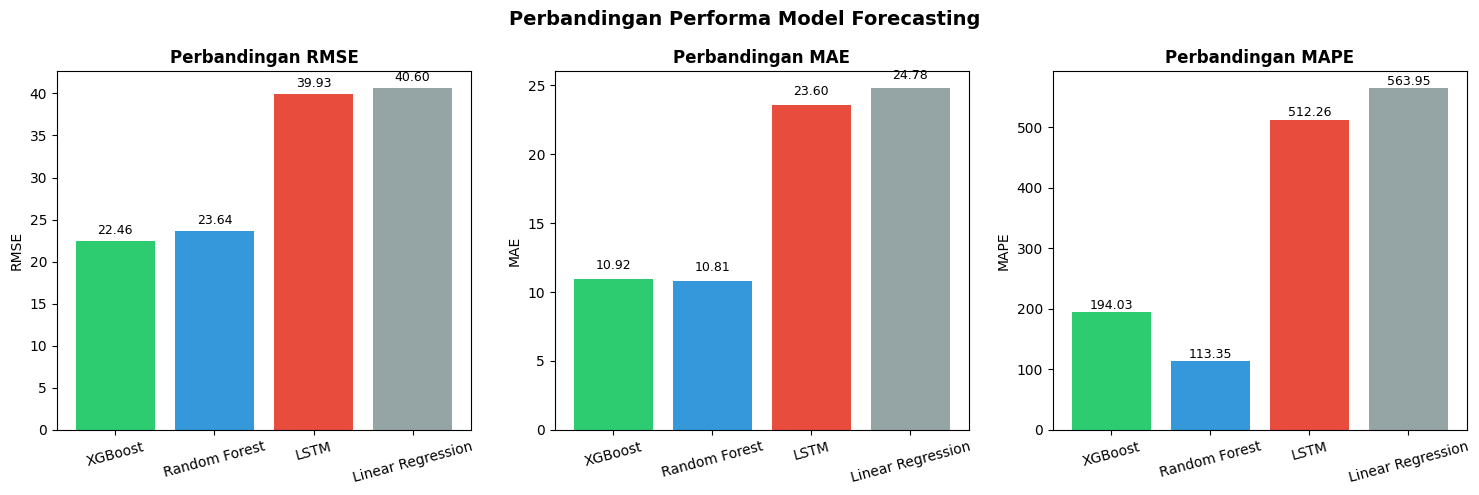

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrik = ['RMSE', 'MAE', 'MAPE']
warna  = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']  # hijau=terbaik

for i, m in enumerate(metrik):
    bars = axes[i].bar(hasil['Model'], hasil[m], color=warna)
    axes[i].set_title(f'Perbandingan {m}', fontweight='bold')
    axes[i].set_ylabel(m)
    axes[i].tick_params(axis='x', rotation=15)
    
    # Tambah nilai di atas bar
    for bar, val in zip(bars, hasil[m]):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                     bar.get_height() + 0.5,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Perbandingan Performa Model Forecasting', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/grafik_evaluasi.png', dpi=150)
plt.show()

Highlight Model Terbaik

In [3]:
terbaik = hasil.loc[hasil['RMSE'].idxmin()]

print("="*40)
print("   MODEL TERBAIK: XGBoost")
print("="*40)
print(f"   RMSE : {terbaik['RMSE']}")
print(f"   MAE  : {terbaik['MAE']}")
print(f"   MAPE : {terbaik['MAPE']}%")
print("="*40)

   MODEL TERBAIK: XGBoost
   RMSE : 22.4642
   MAE  : 10.9228
   MAPE : 194.03%


Simpan Ringkasan untuk Jurnal

In [5]:
ringkasan = """
RINGKASAN HASIL EKSPERIMEN
===========================
Dataset    : Olist Brazilian E-Commerce
Model      : Linear Regression, Random Forest, XGBoost, LSTM
Metrik     : RMSE, MAE, MAPE

HASIL:
- XGBoost   → RMSE: 22.46 | MAE: 10.92 | MAPE: 194.03%  ← TERBAIK
- Ran.Forest→ RMSE: 23.64 | MAE: 10.81 | MAPE: 113.35%
- LSTM      → RMSE: 39.93 | MAE: 23.60 | MAPE: 512.26%
- Lin.Reg   → RMSE: 40.60 | MAE: 24.78 | MAPE: 563.95%

KESIMPULAN:
XGBoost unggul pada RMSE dan MAE.
Random Forest unggul pada MAPE.
Model ML klasik lebih baik dari Deep Learning (LSTM)
untuk data tabular e-commerce ini.
"""

with open('../results/ringkasan_hasil.txt', 'w', encoding='utf-8') as f:
    f.write(ringkasan)
    
print(ringkasan)
print("Ringkasan tersimpan!")


RINGKASAN HASIL EKSPERIMEN
Dataset    : Olist Brazilian E-Commerce
Model      : Linear Regression, Random Forest, XGBoost, LSTM
Metrik     : RMSE, MAE, MAPE

HASIL:
- XGBoost   → RMSE: 22.46 | MAE: 10.92 | MAPE: 194.03%  ← TERBAIK
- Ran.Forest→ RMSE: 23.64 | MAE: 10.81 | MAPE: 113.35%
- LSTM      → RMSE: 39.93 | MAE: 23.60 | MAPE: 512.26%
- Lin.Reg   → RMSE: 40.60 | MAE: 24.78 | MAPE: 563.95%

KESIMPULAN:
XGBoost unggul pada RMSE dan MAE.
Random Forest unggul pada MAPE.
Model ML klasik lebih baik dari Deep Learning (LSTM)
untuk data tabular e-commerce ini.

Ringkasan tersimpan!
